# Sensor and Sensing Technology Classification

Classifies the screened walkability corpus by sensing modality: the technology used
as the measurement instrument (street-view imagery, wearable devices, remote sensing,
environmental/IoT sensors, traffic and infrastructure sensors, acoustic sensors).
Companion axis to the walkability dimension classification
(`06_1_Walkability_Dimension_Classification.ipynb`).

Sensor and technology names are concrete technical terms that tend to appear
near-literally in text, so classification uses keyword-anchored semantic similarity
rather than zero-shot NLI entailment. Each macro category is scored by its strongest
matching keyword (sentence-level, max-pooled), and the assignment threshold is
calibrated against the labeled screening validation set (`real.json`) via ROC-based
target-recall selection, rather than a fixed or heuristic cutoff.

# Import Required Libraries

In [16]:
import json
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

# Load and Prepare Data

In [17]:
df = pd.read_json("../data/05_filtered_walkability_applications.json")
print(f"Total articles processed: {len(df)}")

Total articles processed: 968


# Define Sensor and Sensing Technology Taxonomy

In [18]:
with open("../data/config/sensor_technology_domains.json", "r", encoding="utf8") as f:
    sensor_technologies = json.load(f)

keyword_to_macro = {}
for macro_category, keywords in sensor_technologies.items():
    for keyword in keywords:
        keyword_to_macro[keyword] = macro_category

keyword_list = list(keyword_to_macro.keys())
print(f"Total number of keyword phrases: {len(keyword_list)}")
print(f"Macro sensor categories: {list(sensor_technologies.keys())}")

Total number of keyword phrases: 47
Macro sensor categories: ['Street-View and Image-Based Sensing', 'Remote and Aerial Sensing', 'Wearable and Mobile Sensing', 'Environmental and IoT Sensing', 'Traffic and Infrastructure Sensing', 'Acoustic Sensing']


# Set Up Semantic Matching Environment

In [19]:
DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

sbert_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=DEVICE)
keyword_embeddings = sbert_model.encode(keyword_list, convert_to_tensor=True)

Using device: cuda


# Detection Function

In [20]:
def detect_sensor_technologies(text, top_k_per_segment=5):
    """Per-macro-category score: the highest keyword similarity found across the
    text's sentences (sentence-level, max-pooled)."""
    empty_result = {
        "matched_keywords": [],
        "keyword_scores": {},
        "macro_scores": {cat: 0.0 for cat in sensor_technologies},
    }
    if text is None or not isinstance(text, str) or text.strip() == "":
        return empty_result

    sentences = re.split(r"[.!?]", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    text_segments = sentences if len(sentences) > 3 else [text]

    try:
        segment_embeddings = sbert_model.encode(text_segments, convert_to_tensor=True)
        similarities = util.pytorch_cos_sim(segment_embeddings, keyword_embeddings)
        max_sim_per_keyword = similarities.max(dim=0).values
        keyword_scores = {keyword_list[i]: max_sim_per_keyword[i].item() for i in range(len(keyword_list))}
    except Exception as e:
        print(f"Error in semantic matching: {e}")
        return empty_result

    matched_keywords = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_segment]
    macro_scores = {cat: 0.0 for cat in sensor_technologies}
    for keyword, score in keyword_scores.items():
        macro_category = keyword_to_macro[keyword]
        macro_scores[macro_category] = max(macro_scores[macro_category], score)

    return {"matched_keywords": matched_keywords, "keyword_scores": keyword_scores, "macro_scores": macro_scores}

# Apply Detection to the Corpus

In [21]:
df_filtered = df[df["introduction"].str.strip().astype(bool)].copy()
print(f"Classifying introductions from {len(df_filtered)} abstracts...")

tqdm.pandas(desc="Detecting sensor technologies")
detection_results = df_filtered["introduction"].progress_apply(detect_sensor_technologies)

df_filtered["sensor_matched_keywords"] = detection_results.apply(lambda r: r["matched_keywords"])
df_filtered["sensor_macro_scores"] = detection_results.apply(lambda r: r["macro_scores"])

Classifying introductions from 968 abstracts...


Detecting sensor technologies: 100%|██████████| 968/968 [00:56<00:00, 17.27it/s]


# Calibrate the Threshold Against `real.json`

In [22]:
real_df = pd.read_json("../model/dataset/real.json")

REAL_TEXT_FIELD_CANDIDATES = ["introduction", "contribution", "abstract", "text", "contribution_text"]
REAL_LABEL_FIELD_CANDIDATES = ["label", "is_walkability_related", "walkability", "y", "class"]
POSITIVE_LABEL_VALUES = {1, "1", True, "true", "True", "positive", "Positive", "yes", "Yes",
                          "Sensing of walkability dimension", "sensing of walkability dimension"}

def get_text(record, field_candidates=REAL_TEXT_FIELD_CANDIDATES):
    for field in field_candidates:
        val = record.get(field)
        if isinstance(val, str) and val.strip():
            return val.strip()
    return None

def get_label(record, field_candidates=REAL_LABEL_FIELD_CANDIDATES, positive_values=POSITIVE_LABEL_VALUES):
    for field in field_candidates:
        if field in record and record[field] is not None:
            return 1 if record[field] in positive_values else 0
    return None

real_df["text"] = real_df.apply(lambda r: get_text(r.to_dict()), axis=1)
real_df["label"] = real_df.apply(lambda r: get_label(r.to_dict()), axis=1)
real_df = real_df.dropna(subset=["text", "label"]).reset_index(drop=True)
real_df["label"] = real_df["label"].astype(int)

tqdm.pandas(desc="Detecting sensor technologies in real.json")
real_detection = real_df["text"].progress_apply(detect_sensor_technologies)
real_df["macro_scores"] = real_detection.apply(lambda r: r["macro_scores"])
real_df["best_sensor_score"] = real_df["macro_scores"].apply(lambda s: max(s.values()))

print(f"Loaded {len(real_df)} labeled records from real.json "
      f"({real_df['label'].sum()} positive / confirmed sensor-based walkability-dimension articles)")

Detecting sensor technologies in real.json:   0%|          | 0/100 [00:00<?, ?it/s]

Detecting sensor technologies in real.json: 100%|██████████| 100/100 [00:13<00:00,  7.63it/s]

Loaded 100 labeled records from real.json (46 positive / confirmed sensor-based walkability-dimension articles)


In [23]:
def threshold_for_target_recall(y_true, scores, target_recall):
    """Lowest score threshold such that recall on y_true >= target_recall, using the
    full ROC curve (both classes)."""
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    valid = tpr >= target_recall
    if not valid.any():
        best_idx = int(np.argmax(tpr))
        return float(thresholds[best_idx]), float(tpr[best_idx])
    candidate_idxs = np.where(valid)[0]
    best_idx = candidate_idxs[np.argmax(thresholds[candidate_idxs])]
    return float(thresholds[best_idx]), float(tpr[best_idx])


TARGET_SENSOR_RECALL = 0.95

CALIBRATED_THRESHOLD, achieved_recall = threshold_for_target_recall(
    real_df["label"], real_df["best_sensor_score"], TARGET_SENSOR_RECALL
)

print(f"Calibrated threshold: {CALIBRATED_THRESHOLD:.4f}")
print(f"Achieved recall among confirmed positives at this threshold: {achieved_recall:.3f}")

Calibrated threshold: 0.4218
Achieved recall among confirmed positives at this threshold: 0.957


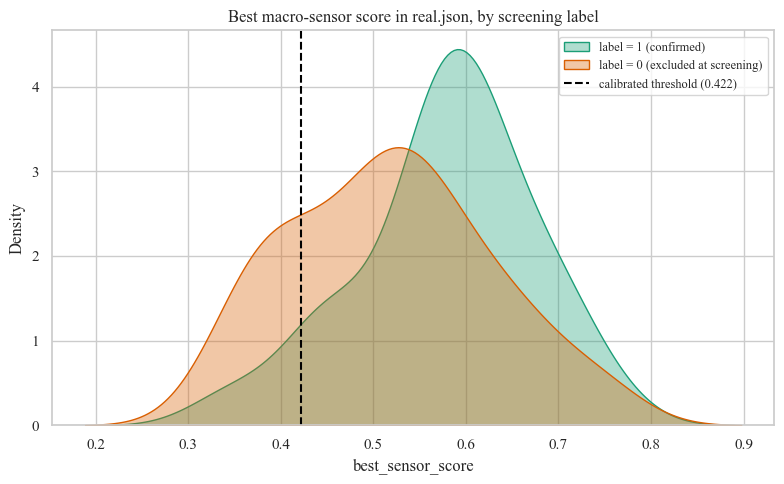

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
for label_value, label_name, color in [(1, "label = 1 (confirmed)", "#1b9e77"),
                                        (0, "label = 0 (excluded at screening)", "#d95f02")]:
    subset = real_df.loc[real_df["label"] == label_value, "best_sensor_score"]
    sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35, color=color, label=label_name, clip=(0, 1))
ax.axvline(CALIBRATED_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"calibrated threshold ({CALIBRATED_THRESHOLD:.3f})")
ax.set_title("Best macro-sensor score in real.json, by screening label")
ax.set_xlabel("best_sensor_score")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Assign Macro Sensor Categories

In [25]:
CONFIG_SCORE_THRESHOLD = CALIBRATED_THRESHOLD

def assign_macro_sensor_categories(macro_scores, threshold):
    return [category for category, score in macro_scores.items() if score >= threshold]

df_filtered["macro_sensor_types"] = df_filtered["sensor_macro_scores"].apply(
    lambda scores: assign_macro_sensor_categories(scores, CONFIG_SCORE_THRESHOLD)
)

category_counts = Counter()
for categories in df_filtered["macro_sensor_types"]:
    category_counts.update(categories)

print(f"Threshold used: {CONFIG_SCORE_THRESHOLD:.4f}\n")
print("Sensor category distribution:")
for category, count in category_counts.most_common():
    print(f"  - {category}: {count} abstracts")

avg_categories = np.mean([len(c) for c in df_filtered["macro_sensor_types"]])
multi_category = sum(1 for c in df_filtered["macro_sensor_types"] if len(c) > 1)
print(f"\nAverage sensor categories per abstract: {avg_categories:.2f}")
print(f"Abstracts with multiple sensor categories: {multi_category} ({multi_category/len(df_filtered)*100:.2f}%)")

Threshold used: 0.4218

Sensor category distribution:
  - Street-View and Image-Based Sensing: 331 abstracts
  - Wearable and Mobile Sensing: 118 abstracts
  - Traffic and Infrastructure Sensing: 113 abstracts
  - Remote and Aerial Sensing: 61 abstracts
  - Acoustic Sensing: 33 abstracts
  - Environmental and IoT Sensing: 26 abstracts

Average sensor categories per abstract: 0.70
Abstracts with multiple sensor categories: 165 (17.05%)


# Visualize Sensor Category Distribution

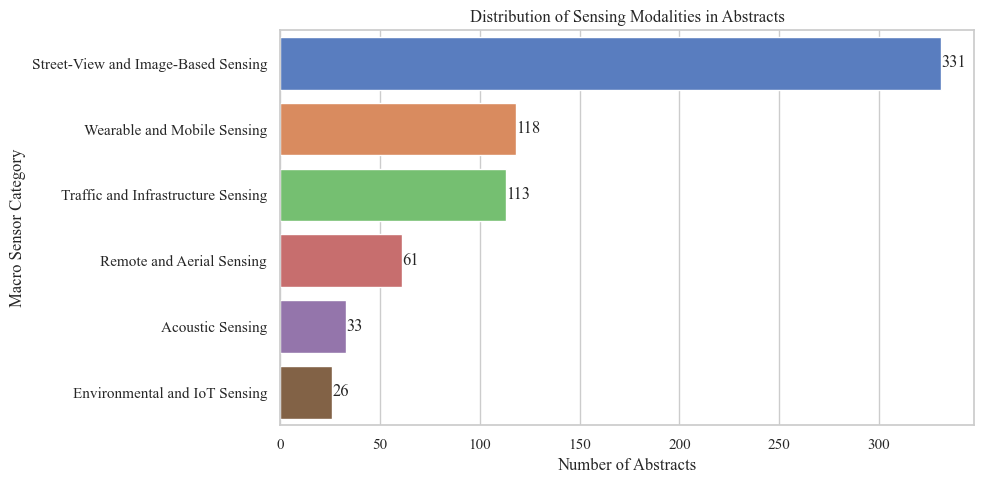

In [26]:
palette = sns.color_palette("muted", n_colors=len(category_counts))
categories_list = [category for category, count in category_counts.most_common()]
counts = [count for category, count in category_counts.most_common()]

plt.figure(figsize=(10, 5))
sns.barplot(x=counts, y=categories_list, hue=categories_list, palette=palette, legend=False)
plt.xlabel("Number of Abstracts")
plt.ylabel("Macro Sensor Category")
plt.title("Distribution of Sensing Modalities in Abstracts")

for i, count in enumerate(counts):
    plt.text(count + 0.2, i, str(count), va="center")

plt.tight_layout()
plt.show()

# Filter Articles with No Sensor Category Assigned

In [27]:
no_category_mask = df_filtered["macro_sensor_types"].apply(lambda x: len(x) == 0)
no_category_df = df_filtered[no_category_mask]

df_filtered = df_filtered[~no_category_mask].copy()
df_filtered = df_filtered.reset_index(drop=True)
print(f"Filtered DataFrame size: {len(df_filtered)} articles with an assigned sensor category")
print(f"Articles with no sensor category assigned: {len(no_category_df)}")

Filtered DataFrame size: 484 articles with an assigned sensor category
Articles with no sensor category assigned: 484


# Save the Results

In [28]:
df_filtered.to_json("../data/06_3_classified_sensor_types.json", orient="records", indent=4)
no_category_df.to_json("../data/06_3_1_no_assigned_sensor_types.json", orient="records", indent=4)

print(f"Saved:\n  ../data/06_3_classified_sensor_types.json ({len(df_filtered)} records)"
      f"\n  ../data/06_3_1_no_assigned_sensor_types.json ({len(no_category_df)} records)")

Saved:
  ../data/06_3_classified_sensor_types.json (484 records)
  ../data/06_3_1_no_assigned_sensor_types.json (484 records)


# Merge into the Dimension-Classified File

In [29]:
dimension_path = "../data/06_2_classified_walkability_dimensions.json"
if os.path.exists(dimension_path):
    df_dimensions = pd.read_json(dimension_path)
    merged = df_dimensions.merge(
        df_filtered[["doi", "macro_sensor_types"]], on="doi", how="left"
    )
    merged.to_json("../data/06_4_dimensions_with_sensor_types.json", orient="records", indent=4)
    print(f"Saved ../data/06_4_dimensions_with_sensor_types.json ({len(merged)} records)")
else:
    print(f"{dimension_path} not found -- run the dimension-classification notebook first.")

Saved ../data/06_4_dimensions_with_sensor_types.json (737 records)
